# EDA


In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [2]:
df = pd.read_csv("data/eda.csv")
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,2014-10-13,221900.000
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,2014-12-09,538000.000
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,2015-02-25,180000.000
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,2014-12-09,604000.000
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,2015-02-18,510000.000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float64
 18  sqft_lot15     21

In [4]:
# Convert bedrooms to integer (removes the .000 entirely)
df['bedrooms'] = df['bedrooms'].astype(int)
# Convert floors to integer (removes the .000 entirely)
df['floors'] = df['floors'].astype(int)



# Fill 0 instead of NaN to fix missing data 
df['yr_renovated'] = df['yr_renovated'].fillna(0)
df['waterfront'] = df['waterfront'].fillna(0)
df['sqft_basement'] = df['sqft_basement'].fillna(0)
df['view'] = df['view'].fillna(0)

# Convert waterfront and view to integer (removes the .000 entirely)
df['waterfront'] = df['waterfront'].astype(int)
df['view'] = df['view'].astype(int)

# Convert year renovated to integer + fix the mistake in format writing 
df["yr_renovated"] = df["yr_renovated"].apply(
    lambda x: x / 10 if x > 9999 else x
)
df['yr_renovated'] = df['yr_renovated'].astype(int)

# Round to .xx and only show .xx for the whole dataframe
df = df.round(2)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3,1.00,1180.00,5650.00,1,0,0,3,7,...,0.00,1955,0,98178,47.51,-122.26,1340.00,5650.00,2014-10-13,221900.00
1,6414100192,3,2.25,2570.00,7242.00,2,0,0,3,7,...,400.00,1951,1991,98125,47.72,-122.32,1690.00,7639.00,2014-12-09,538000.00
2,5631500400,2,1.00,770.00,10000.00,1,0,0,3,6,...,0.00,1933,0,98028,47.74,-122.23,2720.00,8062.00,2015-02-25,180000.00
3,2487200875,4,3.00,1960.00,5000.00,1,0,0,5,7,...,910.00,1965,0,98136,47.52,-122.39,1360.00,5000.00,2014-12-09,604000.00
4,1954400510,3,2.00,1680.00,8080.00,1,0,0,3,8,...,0.00,1987,0,98074,47.62,-122.04,1800.00,7503.00,2015-02-18,510000.00


In [5]:
df.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
count,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00
mean,4580474287.77,3.37,2.12,2080.32,15099.41,1.45,0.01,0.23,3.41,7.66,1788.60,285.75,1971.00,68.76,98077.95,47.56,-122.21,1986.62,12758.28,540296.57
std,2876735715.75,0.93,0.77,918.11,41412.64,0.55,0.08,0.76,0.65,1.17,827.76,439.82,29.38,364.04,53.51,0.14,0.14,685.23,27274.44,367368.14
min,1000102.00,1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,3.00,370.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00,78000.00
25%,2123049175.00,3.00,1.75,1430.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00,322000.00
50%,3904930410.00,3.00,2.25,1910.00,7618.00,1.00,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00,450000.00
75%,7308900490.00,4.00,2.50,2550.00,10685.00,2.00,0.00,0.00,4.00,8.00,2210.00,550.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00,645000.00
max,9900000190.00,33.00,8.00,13540.00,1651359.00,3.00,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,98199.00,47.78,-121.32,6210.00,871200.00,7700000.00


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'sqft_living'}>],
       [<Axes: title={'center': 'sqft_lot'}>,
        <Axes: title={'center': 'floors'}>,
        <Axes: title={'center': 'waterfront'}>,
        <Axes: title={'center': 'view'}>],
       [<Axes: title={'center': 'condition'}>,
        <Axes: title={'center': 'grade'}>,
        <Axes: title={'center': 'sqft_above'}>,
        <Axes: title={'center': 'sqft_basement'}>],
       [<Axes: title={'center': 'yr_built'}>,
        <Axes: title={'center': 'yr_renovated'}>,
        <Axes: title={'center': 'zipcode'}>,
        <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'sqft_living15'}>,
        <Axes: title={'center': 'sqft_lot15'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

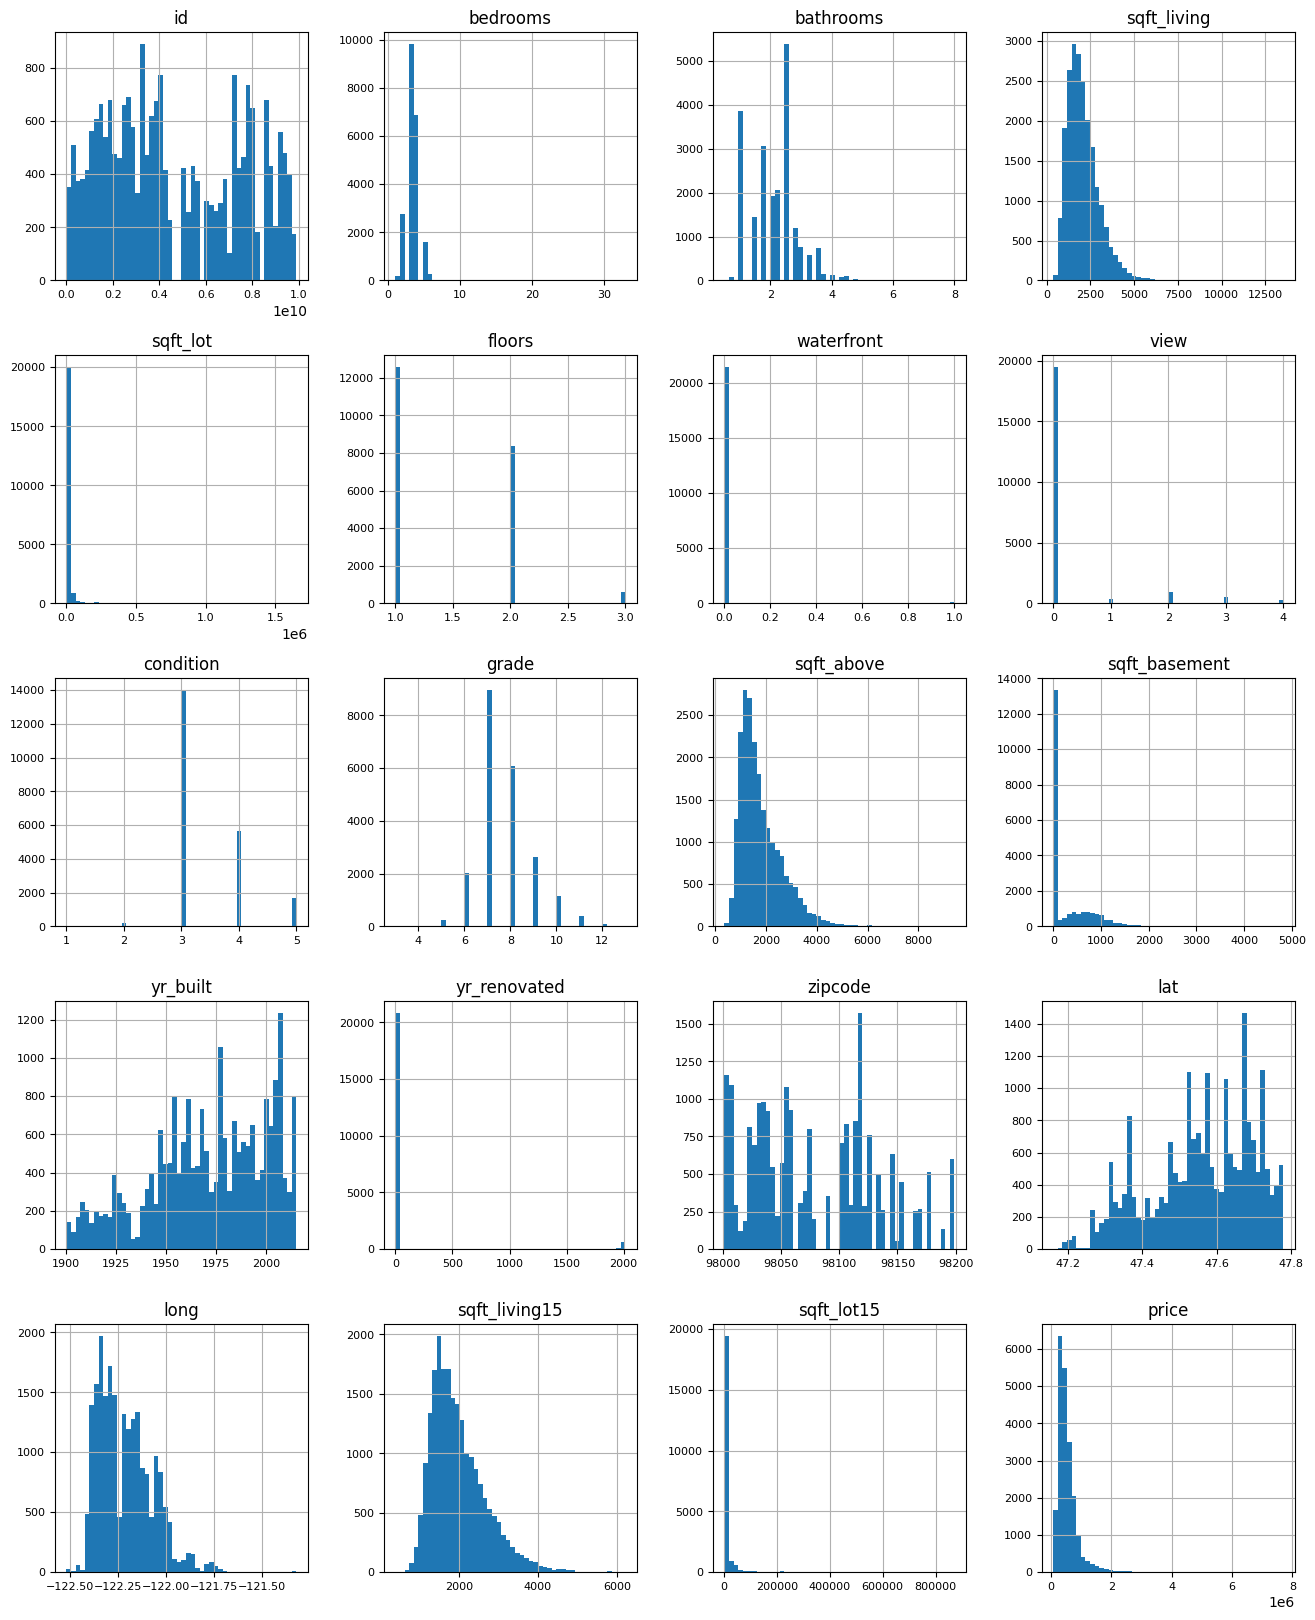

In [6]:
#Lets's plot all the data to get the better understanding of the distribution
df.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

In [7]:
# Finding the features most correlated with the price of the houses 
df_num = df.select_dtypes(include = ['float64', 'int64'])
#df_num.head()

df_num = df_num.corr()['price'][:-1] # -1 because the latest row is SalePrice
golden_features_list = df_num[abs(df_num) > 0.5].sort_values(ascending=False)
print("There is {} strongly correlated values with SalePrice:\n{}".format(len(golden_features_list), golden_features_list))


There is 5 strongly correlated values with SalePrice:
sqft_living     0.70
grade           0.67
sqft_above      0.61
sqft_living15   0.59
bathrooms       0.53
Name: price, dtype: float64


['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'price']


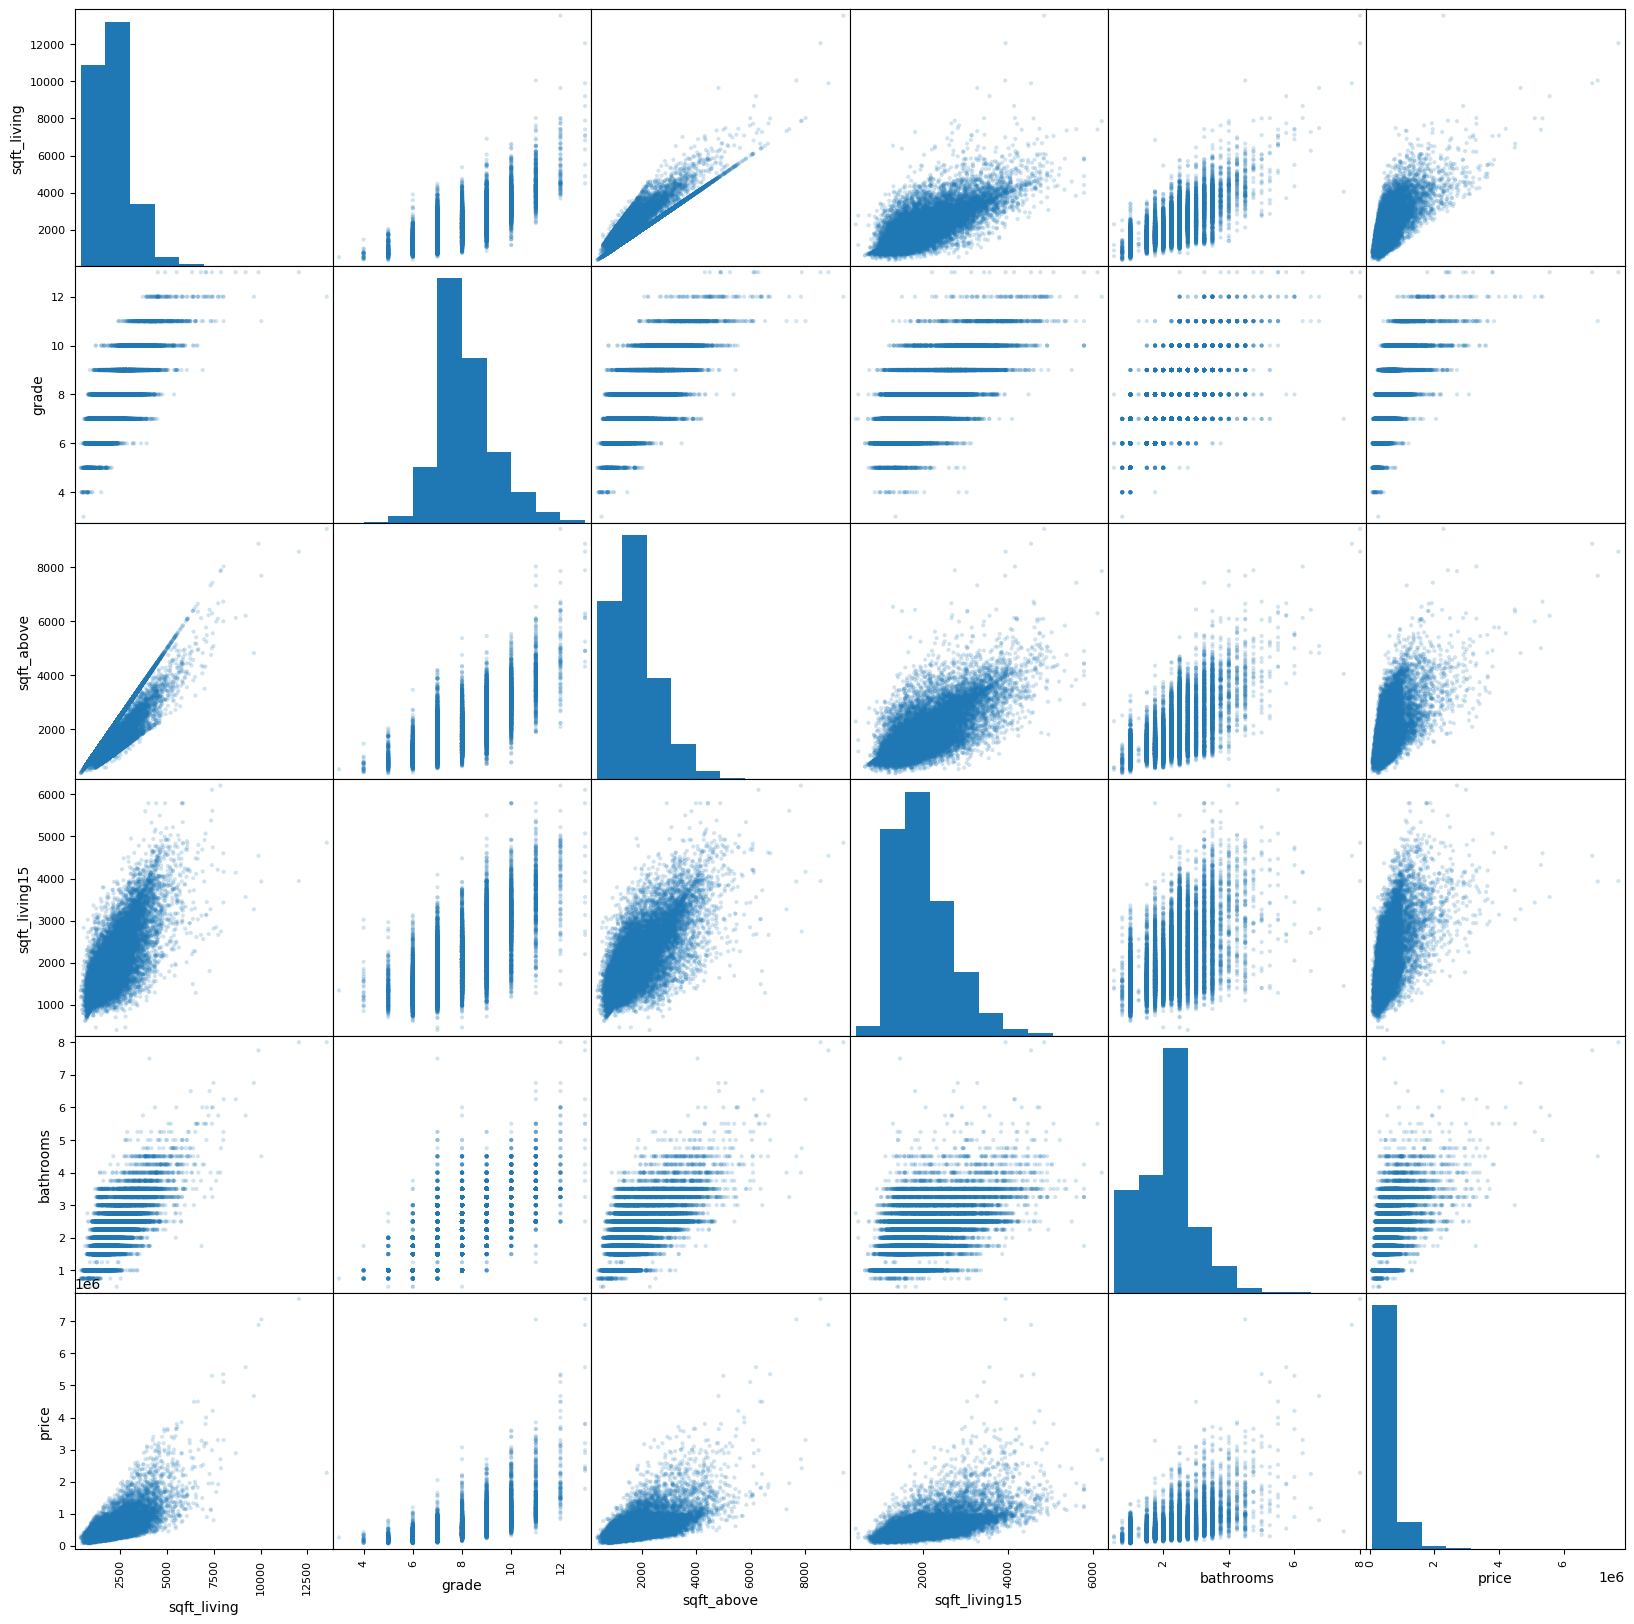

In [8]:
# Scatter-plotting 5 mist correlated ones

from pandas.plotting import scatter_matrix

df_num = df.select_dtypes(include=['float64', 'int64'])
print(df_num.columns.tolist())
cols = golden_features_list.index.tolist() + ['price']
scatter_matrix(df_num[cols], figsize=(20, 20), alpha=0.2, diagonal='hist')
plt.show()


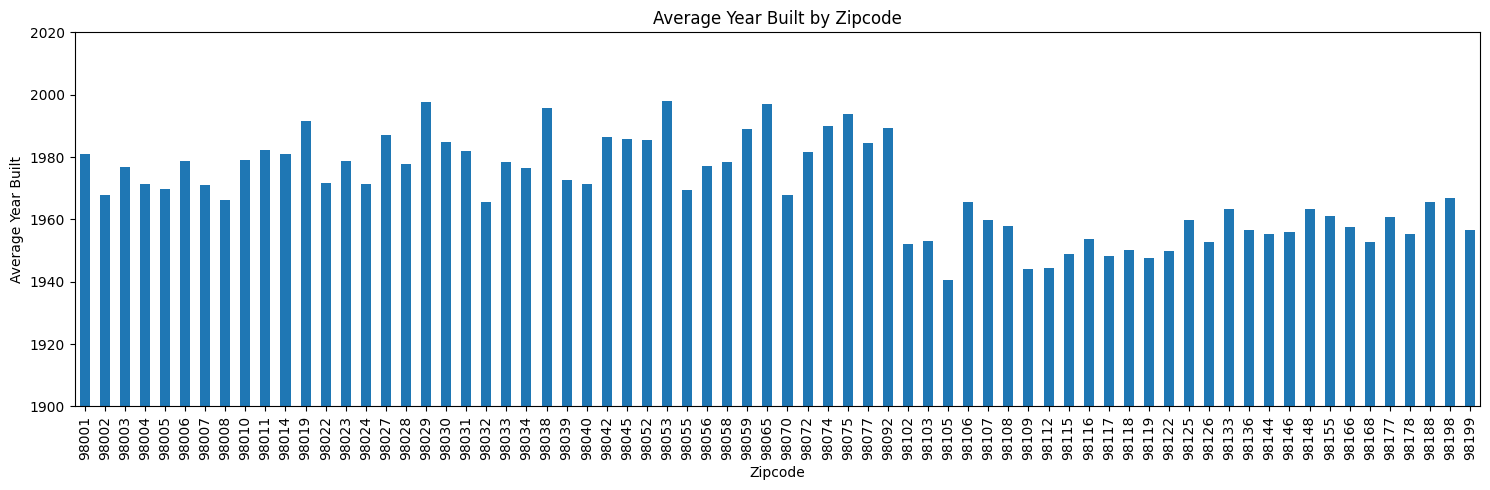

In [9]:
# Finding out historical houses
# In general, good baseline is houses built before 1920 (according to internet research)
# Interesting metric could be to see average age of built per zipcode

# Let's start from checking how many zipcodes are we talking about. UPD: 70
df["zipcode"].nunique()
# And calculating average year of built per zipcode
df.groupby('zipcode')['yr_built'].mean().round().astype(int)
# Build a histogram to visualize this metric now
df.groupby('zipcode')['yr_built'].mean().plot(kind='bar', figsize=(15, 5))
plt.xlabel('Zipcode')
plt.ylabel('Average Year Built')
plt.title('Average Year Built by Zipcode')
plt.tight_layout()
plt.ylim(1900, 2020)
plt.show()



In [10]:
# Let's pick houses older than 1920 and form a dataframe with them

df_historical = df[df['yr_built'] < 1920]
df_historical.head()
df_historical.describe()

# WOW!! it's actually 1450 houses, a lot


# And build a dataframe for Jacob's request

df_proposal = df_historical[df_historical['waterfront'] == 0]
df_proposal.head()
df_proposal.shape[0]
# That's just 1441 that are not waterfront, also shocking info. I thought proportion would be different


df_proposal = df_proposal[df_proposal['bathrooms'] >= 4]
df_proposal.head()
df_proposal.shape[0]
# After bathroom count filter we have 17 results


# Checking for the size over 80000
#df_proposal = df_proposal[df_proposal['sqft_lot'] >= 80000]

# There is none for such request. So I'll just sort descending
df_proposal = df_proposal.sort_values('sqft_lot', ascending=False)
df_proposal.head(17)

# Create a list of zipcodes filtered for golf course related request
zipcodes_filtered = [98118,98144,98108,98107,98116,98126,98125,98065,98022,98010,98011,98005]

# See where they overlap
df_proposal = df_proposal[df_proposal['zipcode'].isin(zipcodes_filtered)]
df_proposal.shape[0]
df_proposal.head()

# Got 5!




,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
5961,5249800010,4,4.25,6410.00,43838.00,2,0,2,4,12,...,800.00,1906,0,98144,47.57,-122.28,2270.00,6630.00,2014-12-03,2730000.00
9405,5700003630,5,4.25,4830.00,8050.00,2,0,0,4,11,...,1120.00,1914,0,98144,47.58,-122.29,4470.00,9194.00,2014-06-30,1930000.00
15346,1175000280,4,4.00,1550.00,6596.00,1,0,0,5,7,...,0.00,1907,0,98107,47.67,-122.40,1830.00,4850.00,2014-11-07,707500.00
3582,9272200090,4,4.50,3780.00,6000.00,2,0,4,4,11,...,1010.00,1910,1977,98116,47.59,-122.39,2660.00,6000.00,2015-02-04,1600000.00
6665,475001235,5,4.00,3400.00,5000.00,2,0,0,3,8,...,1080.00,1900,2013,98107,47.67,-122.36,1910.00,5000.00,2014-08-08,870000.00


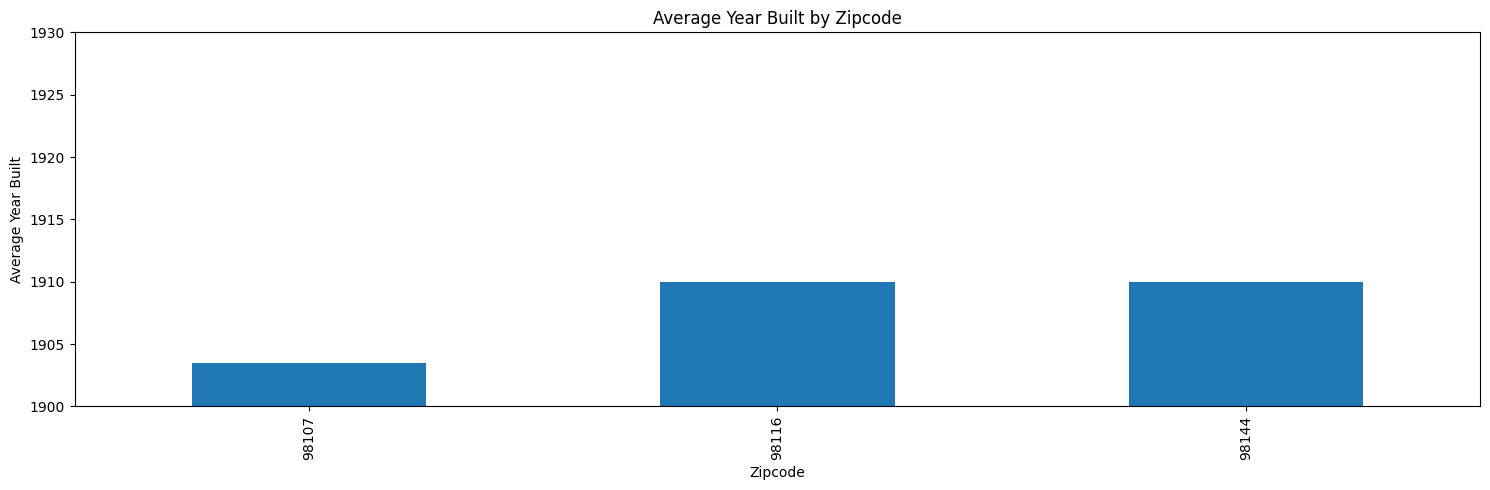

In [11]:
# Build a chart to see houses per zipcodes


df_proposal.groupby('zipcode')['yr_built'].mean().round().astype(int)
# Build a histogram to visualize this metric now
df_proposal.groupby('zipcode')['yr_built'].mean().plot(kind='bar', figsize=(15, 5))
plt.xlabel('Zipcode')
plt.ylabel('Average Year Built')
plt.title('Average Year Built by Zipcode')
plt.tight_layout()
plt.ylim(1900, 1930)
plt.show()

In [12]:
### OLENA CONTINUE FROM HERE
# Olena, add this import seaborn to the file, at the top where the other imports are
import seaborn as sns


## CLARIFICATIONS ON VARIABLES
Some variables in the original dataframes (column headers) are ambiguous, so ahead of a correlation heatmap of the variables, i sought clarifications online. Below are the column headers that were not immediately understandable and their meaning:
- floors	    Number of floors [pending clarification on what exactly 1.5 floors entails] 
- view	        An index from 0 to 4 of how good the view of the property was - OK CLEAR - LARGER BETTER
- condition	    Condition of the house, ranked from 1 to 5 - OK, ASSUMED HIGHER IS BETTER
- grade	        Classification by construction quality which refers to the types of materials used and the quality of workmanship. Buildings of better quality (higher grade) cost more to build per unit of measure and command higher value. - OK HIGHER IS BETTER
- squft_liv15	Average size of interior housing living space for the closest 15 houses, in square feet - OK
- squft_lot15	Average size of land lots for the closest 15 houses, in square feet - OK 

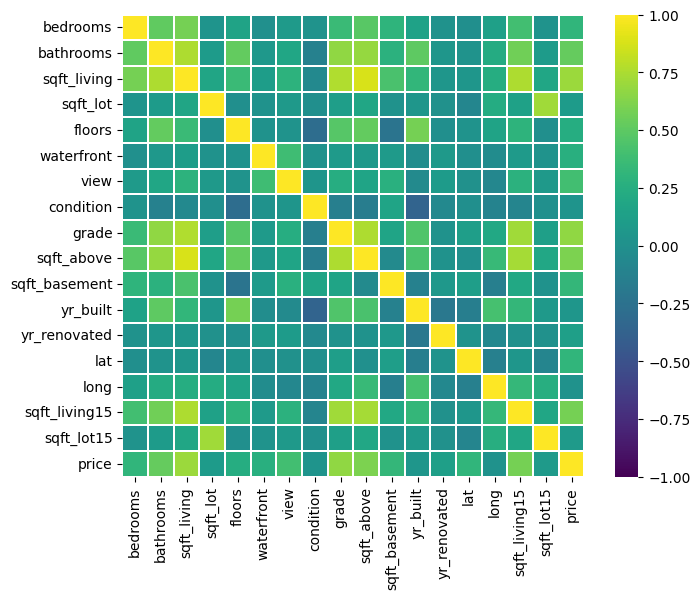

In [13]:
#First an all-in only colors to see if some variable can be excluded for better exploration of the correlations.
# We already exclude id and zipcode since the numbers are a characteristic based on the location 
# or database ordering.
corr = df.select_dtypes(include=['float64', 'int64']).drop(['id', 'zipcode'], axis=1).corr()
plt.figure(figsize=(8, 6))

sns.heatmap(corr[(corr >= 0) | (corr <= 0)], 
    cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
    square=True);

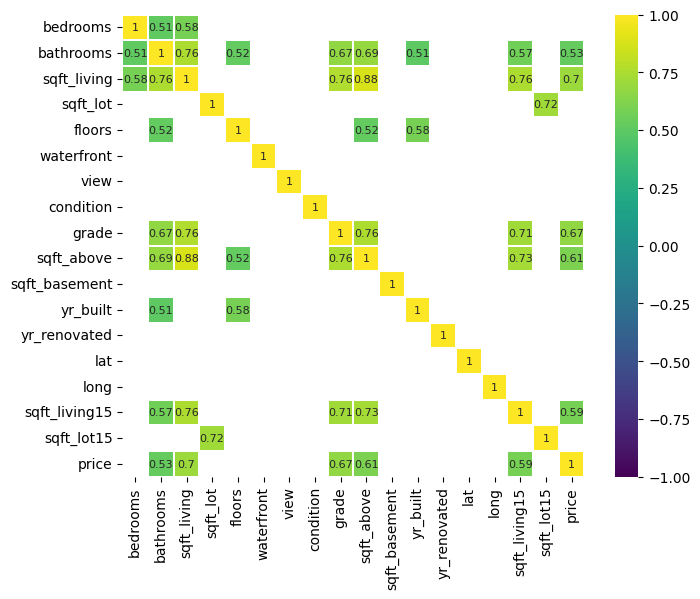

In [14]:
#Let's be more selective and only show the correlations that are above 0.5 or below -0.4 to see if we can find some interesting relationships between the features. 
corr = df.select_dtypes(include=['float64', 'int64']).drop(['id', 'zipcode'], axis=1).corr()
plt.figure(figsize=(8, 6))

sns.heatmap(corr[(corr >= 0.5) | (corr <= -0.4)], 
    cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
    annot=True, annot_kws={"size": 8}, square=True);

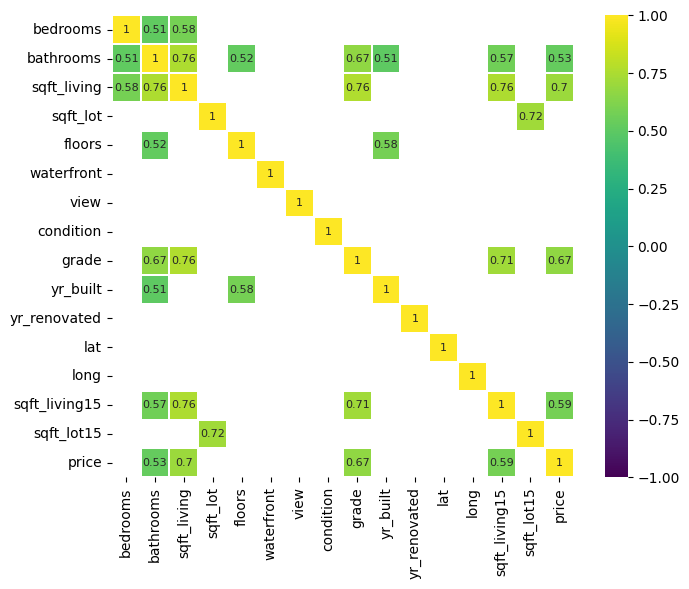

In [15]:
# we can exclude redundant statistics (sqft_above/basement are well represented by Sqft_living).  
# Grade is also correlated with sqft_lliving, but we rather leave it in because it can be an important 
# later filter for our customer JACOB that has unlimited budget. 
corr = df.select_dtypes(include=['float64', 'int64']).drop(['id', 'zipcode', 'sqft_above', 'sqft_basement'], axis=1).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr[(corr >= 0.5) | (corr <= -0.4)], 
    cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
    annot=True, annot_kws={"size": 8}, square=True);

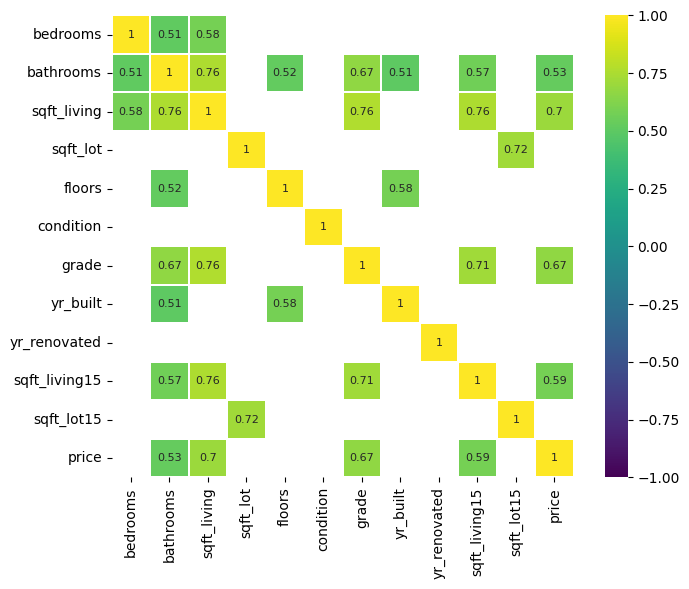

In [16]:
# Finally, some variables are of a nature that makes statistical analysis wonky. 
# Let's try one last chart excluding the empty rows:
# - waterfront (binary)
# - view (category based, subjective and integer)
# - lat/long (geo, the correlations are meaningless) better filtered by hand-picked zipcodes
corr = df.select_dtypes(include=['float64', 'int64']).drop(['id', 'zipcode', 'sqft_above', 'sqft_basement', 'waterfront', 'view', 'lat', 'long'], axis=1).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr[(corr >= 0.5) | (corr <= -0.4)], 
    cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
    annot=True, annot_kws={"size": 8}, square=True);

### PRICE PER SQFT BEGINS HERE, ADDED 0619


In [18]:
df['px_per_sqft'] = df['price'] / df['sqft_living']
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,px_per_sqft
0,7129300520,3,1.00,1180.00,5650.00,1,0,0,3,7,...,1955,0,98178,47.51,-122.26,1340.00,5650.00,2014-10-13,221900.00,188.05
1,6414100192,3,2.25,2570.00,7242.00,2,0,0,3,7,...,1951,1991,98125,47.72,-122.32,1690.00,7639.00,2014-12-09,538000.00,209.34
2,5631500400,2,1.00,770.00,10000.00,1,0,0,3,6,...,1933,0,98028,47.74,-122.23,2720.00,8062.00,2015-02-25,180000.00,233.77
3,2487200875,4,3.00,1960.00,5000.00,1,0,0,5,7,...,1965,0,98136,47.52,-122.39,1360.00,5000.00,2014-12-09,604000.00,308.16
4,1954400510,3,2.00,1680.00,8080.00,1,0,0,3,8,...,1987,0,98074,47.62,-122.04,1800.00,7503.00,2015-02-18,510000.00,303.57


## HYPOTHESIS 1
# Now calculate the avg px_per_sqft for these types of houses (separate table): 
- no waterfront, no view
- only waterfront
- only view (any and per level 1-4)
- both waterfront and view_any

In [31]:
# filters and means
results = {
    'no_waterfront_no_view': df[(df['waterfront'] == 0) & (df['view'] == 0)]['px_per_sqft'].mean(),
    'only_waterfront':       df[(df['waterfront'] == 1) & (df['view'] == 0)]['px_per_sqft'].mean(),
    'only_view_any':         df[(df['waterfront'] == 0) & (df['view'] > 0)]['px_per_sqft'].mean(),
    'only_view1':         df[(df['waterfront'] == 0) & (df['view'] == 1)]['px_per_sqft'].mean(),
    'only_view2':         df[(df['waterfront'] == 0) & (df['view'] == 2)]['px_per_sqft'].mean(),
    'only_view3':         df[(df['waterfront'] == 0) & (df['view'] == 3)]['px_per_sqft'].mean(),
    'only_view4':         df[(df['waterfront'] == 0) & (df['view'] == 4)]['px_per_sqft'].mean(),
    'both_waterfront_view_any':                  df[(df['waterfront'] == 1) & (df['view'] > 0)]['px_per_sqft'].mean(),
}

pd.Series(results)

no_waterfront_no_view      256.89
only_waterfront            717.19
only_view_any              317.55
only_view1                 320.05
only_view2                 303.18
only_view3                 318.43
only_view4                 381.42
both_waterfront_view_any   511.59
dtype: float64

This concludes that waterfront adds the largest value. The influence in view over pricing is mixed, probably unreliable or inconsistent view 'grades' attributed to the houses by different evaluators. view 4 is the highest, but the view 1 being higher than view 2 points to that inconsistency, and there is a concrete possibility that people inputting data consider view a binary yes/no 1/0 type entry and mess-up the statistics. 
Somewhat surprisingly, the view+waterfront average is not higher than just waterfront - can be explained by the fact that most evaluators consider view associated with altitude which makes a good view mutally exlcusive to waterfront. 

## HYPOTHESIS 3

In [ ]:
# now let's test house age (renovated or not) versus the px-per-sqft
# filters and means
results = {
    'overall':       df['px_per_sqft'].corr(df['yr_built']),
    'not_renovated': df[df['yr_renovated'] == 0]['px_per_sqft'].corr(df[df['yr_renovated'] == 0]['yr_built']),
    'renovated':     df[df['yr_renovated'] > 0]['px_per_sqft'].corr(df[df['yr_renovated'] > 0]['yr_built']),
}

pd.Series(results)


overall         -0.29
not_renovated   -0.29
renovated       -0.06
dtype: float64

# CHARTS
Now building the scatter plot for correlation.

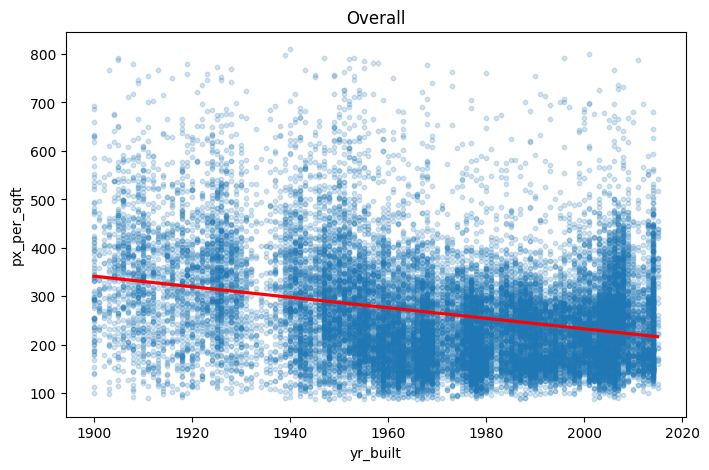

In [30]:
# Overall
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x='yr_built', y='px_per_sqft', ax=ax,
            scatter_kws={'alpha': 0.2, 's': 10}, line_kws={'color': 'red'})
ax.set_title('Overall')
plt.show()

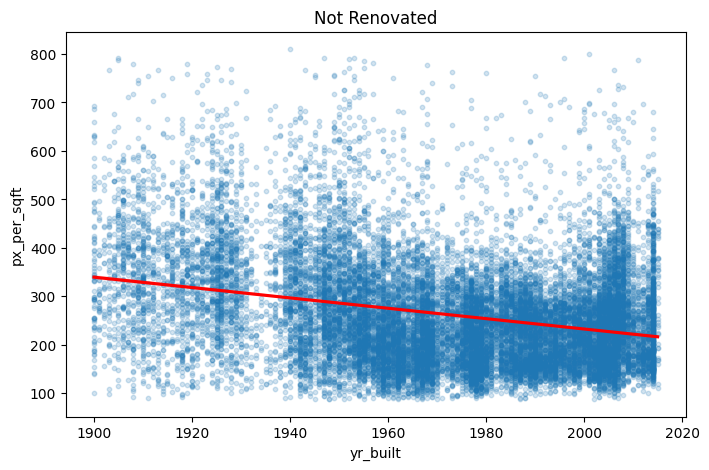

In [ ]:
# Not Renovated
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df[df['yr_renovated'] == 0], x='yr_built', y='px_per_sqft', ax=ax,
            scatter_kws={'alpha': 0.2, 's': 10}, line_kws={'color': 'red'})
ax.set_title('Not Renovated')
plt.show()

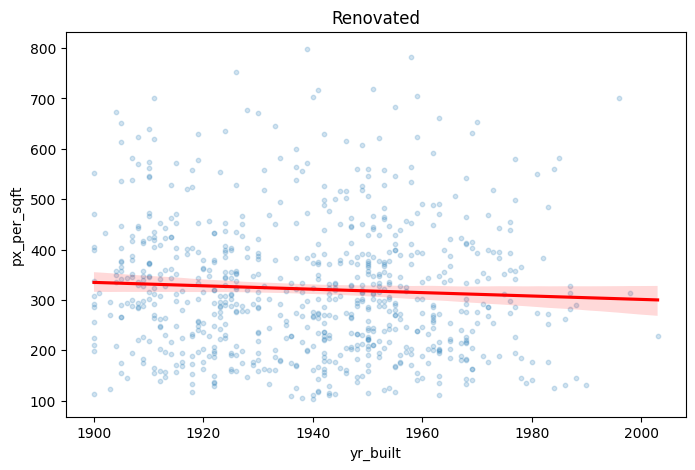

In [29]:
# Renovated
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df[df['yr_renovated'] > 0], x='yr_built', y='px_per_sqft', ax=ax,
            scatter_kws={'alpha': 0.2, 's': 10}, line_kws={'color': 'red'})
ax.set_title('Renovated')
plt.show()

#OBSERVATIONS
ALREADY WRITTEN ION THE DRAFT PRESENTATION.

## PRICE EXPLORATION - TESTING: is the initial set of houses really suitable?


In [ ]:
# ORDER BY px_per_sqft
cols = ['id', 'price', 'sqft_living', 'sqft_lot', 'zipcode',
        'yr_built', 'yr_renovated', 'condition', 'grade',
        'bedrooms', 'bathrooms', 'px_per_sqft']

(df[df['waterfront'] == 0]
   .sort_values('px_per_sqft', ascending=False)
   .head(50)
   [cols]
)


,id,price,sqft_living,sqft_lot,zipcode,yr_built,yr_renovated,condition,grade,bedrooms,bathrooms,px_per_sqft
19321,6021500970,874950.00,1080.00,4000.00,98117,1940,0,3,7,2,1.00,810.14
10435,1118000320,3400000.00,4260.00,11765.00,98112,1939,2010,3,11,4,4.00,798.12
8614,6303400395,325000.00,410.00,8636.00,98146,1953,0,2,4,1,0.75,792.68
9305,4389200610,903000.00,1140.00,7800.00,98004,1947,0,4,6,2,1.50,792.11
6237,5536100010,1050000.00,1330.00,9729.00,98004,1952,0,3,6,4,1.00,789.47
12744,2767603026,425000.00,540.00,2500.00,98107,1905,0,3,5,2,1.00,787.04
7425,5316100780,2580000.00,3280.00,3800.00,98112,2011,0,3,11,4,3.50,786.59
18861,9808700025,1500000.00,1910.00,21374.00,98004,1955,0,1,8,3,1.50,785.34
9285,1257201095,826000.00,1060.00,6120.00,98103,1908,0,3,7,2,1.00,779.25
8330,2770604925,1300000.00,1670.00,6400.00,98119,1919,0,3,8,5,1.00,778.44


In [34]:
# ORDER BY price
cols = ['id', 'price', 'sqft_living', 'sqft_lot', 'zipcode',
        'yr_built', 'yr_renovated', 'condition', 'grade',
        'bedrooms', 'bathrooms', 'px_per_sqft']

(df[df['waterfront'] == 0]
   .sort_values('price', ascending=False)
   .head(50)
   [cols]
)

,id,price,sqft_living,sqft_lot,zipcode,yr_built,yr_renovated,condition,grade,bedrooms,bathrooms,px_per_sqft
7245,6762700020,7700000.00,12050.00,27600.00,98102,1910,1987,4,13,6,8.00,639.00
9245,9208900037,6890000.00,9890.00,31374.00,98039,2001,0,3,13,6,7.75,696.66
4407,2470100110,5570000.00,9200.00,35069.00,98039,2001,0,3,13,5,5.75,605.43
1446,8907500070,5350000.00,8000.00,23985.00,98004,2009,0,3,12,5,5.00,668.75
8629,3835500195,4490000.00,6430.00,27517.00,98004,2001,0,3,12,4,3.00,698.29
12358,6065300370,4210000.00,7440.00,21540.00,98006,2003,0,3,12,5,6.00,565.86
4145,6447300265,4000000.00,7080.00,16573.00,98039,2008,0,3,12,4,5.50,564.97
7028,853200010,3800000.00,7050.00,42840.00,98004,1978,0,4,13,5,5.50,539.01
19002,2303900100,3800000.00,5510.00,35000.00,98177,1997,0,3,13,3,4.25,689.66
16288,7397300170,3710000.00,5550.00,28078.00,98039,2000,0,4,12,4,3.50,668.47
